# Day 8 - Lab 1: Vision-Enabled UI/UX Agents

**Objective:** Use multi-modal vision models to generate a frontend UI from a design image, and then use a second agent to perform an automated design review.

**Estimated Time:** 90 minutes

**Introduction:**
Welcome to Day 8! Today, we'll explore one of the most exciting advancements in AI: vision. We will use a vision-capable model to act as a frontend developer, translating a design image directly into code. Then, we will create a second "UI/UX Critic" agent to automate the design review process, demonstrating a complete, AI-assisted frontend workflow.

For definitions of key terms used in this lab, please refer to the [GLOSSARY.md](../../GLOSSARY.md).

## Step 1: Setup

For this lab, we need to ensure we are using a vision-capable model. We will configure our `utils.py` helper to use a model like OpenAI's `gpt-4o` or Google's `gemini-2.5-pro`.

**Model Selection:**
This lab requires a vision-capable model. Excellent choices include `gpt-4o`, `gemini-2.5-pro`, or `deepseek-ai/DeepSeek-VL2`.

**Helper Functions Used:**
- `setup_llm_client()`: To configure the API client.
- `get_vision_completion()`: A specialized function to send an image and a text prompt to a vision model.
- `get_completion()`: To send text-only prompts for the refactoring step.
- `save_artifact()`: To save the generated code and the design review.

In [11]:
import sys
import os

# Add the project's root directory to the Python path
try:
    project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
except IndexError:
    project_root = os.path.abspath(os.path.join(os.getcwd()))

if project_root not in sys.path:
    sys.path.insert(0, project_root)

from utils import setup_llm_client, get_vision_completion, get_image_generation_completion, get_completion, save_artifact, clean_llm_output, recommended_models_table
from IPython.display import Image, display, Code

image_client, image_model_name, image_api_provider = setup_llm_client(model_name="gemini-2.5-flash-image-preview")
print(f"✅ Using {image_model_name} for image generation")

# Ensure you select a vision-capable model
vision_client, vision_model_name, vision_api_provider = setup_llm_client(model_name="gemini-2.5-pro")
print(f"✅ Using {vision_model_name} for vision tasks")


if not image_model_name or not vision_model_name:
    print("Could not set up a valid LLM client. Please check your .env file and utils.py configuration.")

2025-11-03 10:09:37,034 ag_aisoftdev.utils INFO LLM Client configured provider=google model=gemini-2.5-flash-image-preview latency_ms=None artifacts_path=None


✅ Using gemini-2.5-flash-image-preview for image generation


2025-11-03 10:09:38,416 ag_aisoftdev.utils INFO LLM Client configured provider=google model=gemini-2.5-pro latency_ms=None artifacts_path=None


✅ Using gemini-2.5-pro for vision tasks


In [ ]:
recommended_models_table()

## Step 2: The Design Screenshot

This is the design we want our AI agent to build. It's a simple login form component. We will provide the URL to this image directly to the model.

Using gemini-2.5-flash-image-preview for image generation...
✅ Generated image saved to: C:\Users\647003\Desktop\repos\AG-AISOFTDEV\artifacts\screens\image_1762183340.png



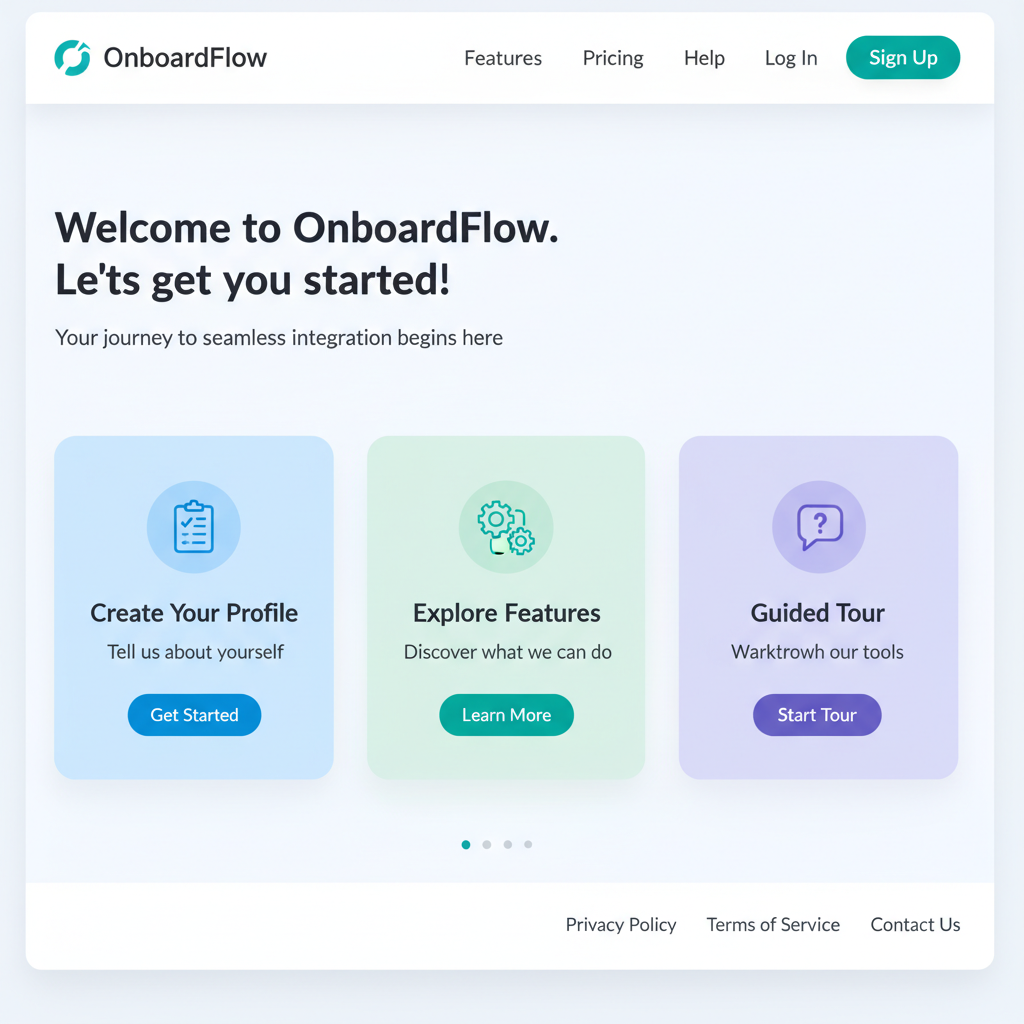

In [16]:
screen_generation_prompt = """A web onboarding tool homepage screen with modern UI design, clean layout, welcome message, and navigation elements.
It should only be the web page as if taken from a screenshot. No background or other noise."""

print(f"Using {image_model_name} for image generation...")
file_path, image_url = get_image_generation_completion(screen_generation_prompt, image_client, image_model_name, image_api_provider)

# Display the generated image if successful
if file_path and image_url:
    print(f"✅ Generated image saved to: {file_path}")
    display(Image(url=image_url))
elif image_url:
    print(f"❌ Image generation failed: {image_url}")
else:
    print("❌ Image generation returned no result")

In [4]:
recommended_models_table()

| Model | Provider | Vision | Image Gen | Audio Transcription | Context Window | Max Output Tokens |
|---|---|---|---|---|---|---|
| claude-opus-4-1-20250805 | anthropic | ✅ | ❌ | ❌ | 200,000 | 100,000 |
| claude-opus-4-20250514 | anthropic | ✅ | ❌ | ❌ | 200,000 | 100,000 |
| claude-sonnet-4-20250514 | anthropic | ✅ | ❌ | ❌ | 1,000,000 | 100,000 |
| codex-mini-latest | openai | ✅ | ❌ | ❌ | 200,000 | 100,000 |
| dall-e-3 | openai | ❌ | ✅ | ❌ | - | - |
| deepseek-ai/DeepSeek-V3 | huggingface | ❌ | ❌ | ❌ | 128,000 | 100,000 |
| deepseek-ai/DeepSeek-V3-Small | huggingface | ❌ | ❌ | ❌ | 128,000 | 100,000 |
| deepseek-ai/DeepSeek-VL2 | huggingface | ✅ | ❌ | ❌ | 32,000 | 8,000 |
| deepseek-ai/DeepSeek-VL2-Small | huggingface | ✅ | ❌ | ❌ | 32,000 | 8,000 |
| deepseek-ai/DeepSeek-VL2-Tiny | huggingface | ✅ | ❌ | ❌ | 32,000 | 8,000 |
| deepseek-ai/Janus-Pro-7B | huggingface | ✅ | ❌ | ❌ | 0 | 0 |
| gemini-2.0-flash | google | ✅ | ❌ | ❌ | 1,048,576 | 8,192 |
| gemini-2.0-flash-lite | google | ✅ | ❌ | ❌ | 1,048,576 | 8,192 |
| gemini-2.0-flash-live-001 | google | ✅ | ❌ | ❌ | 1,048,576 | 8,192 |
| gemini-2.5-flash | google | ✅ | ❌ | ❌ | 1,048,576 | 65,536 |
| gemini-2.5-flash-image-preview | google | ✅ | ✅ | ❌ | 32,768 | 32,768 |
| gemini-2.5-flash-lite | google | ✅ | ❌ | ❌ | 1,048,576 | 65,536 |
| gemini-2.5-pro | google | ✅ | ❌ | ❌ | 1,048,576 | 65,536 |
| gemini-live-2.5-flash-preview | google | ✅ | ❌ | ❌ | 1,048,576 | 8,192 |
| gemini-veo-3 | google | ✅ | ❌ | ❌ | - | - |
| google-cloud/speech-to-text/latest_long | google | ❌ | ❌ | ✅ | - | - |
| google-cloud/speech-to-text/latest_short | google | ❌ | ❌ | ✅ | - | - |
| gpt-4.1 | openai | ✅ | ❌ | ❌ | 1,000,000 | 32,000 |
| gpt-4.1-mini | openai | ✅ | ❌ | ❌ | 1,000,000 | 32,000 |
| gpt-4.1-nano | openai | ✅ | ❌ | ❌ | 1,000,000 | 32,000 |
| gpt-4.5 | openai | ✅ | ❌ | ❌ | 128,000 | 16,384 |
| gpt-4o | openai | ✅ | ❌ | ❌ | 128,000 | 16,384 |
| gpt-4o-mini | openai | ✅ | ❌ | ❌ | 128,000 | 16,384 |
| gpt-5-2025-08-07 | openai | ✅ | ❌ | ❌ | 400,000 | 128,000 |
| gpt-5-mini-2025-08-07 | openai | ✅ | ❌ | ❌ | 400,000 | 128,000 |
| gpt-5-nano-2025-08-07 | openai | ✅ | ❌ | ❌ | 400,000 | 128,000 |
| gpt-image-1 | openai | ✅ | ✅ | ❌ | - | - |
| imagen-3.0-capability-001 | google | ❌ | ❌ | ❌ | - | - |
| imagen-3.0-fast-generate-001 | google | ❌ | ✅ | ❌ | - | - |
| imagen-3.0-generate-001 | google | ❌ | ✅ | ❌ | - | - |
| imagen-3.0-generate-002 | google | ❌ | ✅ | ❌ | - | - |
| imagen-4.0-fast-generate-001 | google | ❌ | ✅ | ❌ | 480 | - |
| imagen-4.0-generate-001 | google | ❌ | ✅ | ❌ | 480 | - |
| imagen-4.0-ultra-generate-001 | google | ❌ | ✅ | ❌ | 480 | - |
| meta-llama/Llama-3.3-70B-Instruct | huggingface | ❌ | ❌ | ❌ | 4,096 | 1,024 |
| meta-llama/Llama-4-Maverick-17B-128E-Instruct | huggingface | ✅ | ❌ | ❌ | 1,000,000 | 100,000 |
| meta-llama/Llama-4-Scout-17B-16E-Instruct | huggingface | ✅ | ❌ | ❌ | 10,000,000 | 100,000 |
| mistralai/Mistral-7B-Instruct-v0.3 | huggingface | ❌ | ❌ | ❌ | 32,768 | 8,192 |
| o3 | openai | ✅ | ❌ | ❌ | 200,000 | 100,000 |
| o4-mini | openai | ✅ | ❌ | ❌ | 200,000 | 100,000 |
| tokyotech-llm/Llama-3.1-Swallow-70B-Instruct-v0.3 | huggingface | ❌ | ❌ | ❌ | 4,096 | 1,024 |
| tokyotech-llm/Llama-3.1-Swallow-8B-Instruct-v0.5 | huggingface | ❌ | ❌ | ❌ | 4,096 | 1,024 |
| whisper-1 | openai | ❌ | ❌ | ✅ | - | - |

'| Model | Provider | Vision | Image Gen | Audio Transcription | Context Window | Max Output Tokens |\n|---|---|---|---|---|---|---|\n| claude-opus-4-1-20250805 | anthropic | ✅ | ❌ | ❌ | 200,000 | 100,000 |\n| claude-opus-4-20250514 | anthropic | ✅ | ❌ | ❌ | 200,000 | 100,000 |\n| claude-sonnet-4-20250514 | anthropic | ✅ | ❌ | ❌ | 1,000,000 | 100,000 |\n| codex-mini-latest | openai | ✅ | ❌ | ❌ | 200,000 | 100,000 |\n| dall-e-3 | openai | ❌ | ✅ | ❌ | - | - |\n| deepseek-ai/DeepSeek-V3 | huggingface | ❌ | ❌ | ❌ | 128,000 | 100,000 |\n| deepseek-ai/DeepSeek-V3-Small | huggingface | ❌ | ❌ | ❌ | 128,000 | 100,000 |\n| deepseek-ai/DeepSeek-VL2 | huggingface | ✅ | ❌ | ❌ | 32,000 | 8,000 |\n| deepseek-ai/DeepSeek-VL2-Small | huggingface | ✅ | ❌ | ❌ | 32,000 | 8,000 |\n| deepseek-ai/DeepSeek-VL2-Tiny | huggingface | ✅ | ❌ | ❌ | 32,000 | 8,000 |\n| deepseek-ai/Janus-Pro-7B | huggingface | ✅ | ❌ | ❌ | 0 | 0 |\n| gemini-2.0-flash | google | ✅ | ❌ | ❌ | 1,048,576 | 8,192 |\n| gemini-2.0-flash-lite 

In [ ]:
login_form_url = "https://i.imgur.com/s42SYz6.png"
display(Image(url=login_form_url))

## Step 3: The Challenges

### Challenge 1 (Foundational): Generating a Monolithic UI Component

**Task:** Use the vision model to generate a single, self-contained React component that replicates the design from the image.

> **Tip for Vision Prompts:** Be specific about the output format. Telling the model you want 'React' and 'Tailwind CSS' is crucial. The more specific your technical constraints, the better the generated code will be.

**Instructions:**
1.  Create a prompt that asks the vision model to act as an expert frontend developer.
2.  The prompt should instruct the model to analyze the image at the provided URL.
3.  Ask it to generate a single React component using Tailwind CSS for styling.
4.  The output should be a single block of JSX code.

**Expected Quality:** A single file's worth of React code that, when rendered, visually approximates the login form in the screenshot.

In [18]:
# Explain the specified image using the vision-capable LLM
image_path = file_path

explain_image_prompt = f"""
You are an expert frontend developer and UI/UX designer. Analyze the provided image and produce a clear, actionable explanation for a developer who will implement the UI.

Please respond in markdown and include the following sections:

1) Summary: One-sentence summary of what this screen is (purpose).
2) Visual Breakdown: Enumerate the visible UI elements (e.g., header, logo, form fields, buttons, icons, images) and approximate positions (top/left/center, grouping).
3) Style Details: Describe colors, font styles (weight/size/line-height if evident), spacing, borders/radii, shadows, and alignment cues.
4) Interaction & Behavior: Identify interactive elements and the likely behaviors (hover/focus states, validation, keyboard affordances).
5) Accessibility Notes: Potential accessibility issues and recommended fixes (labels, contrast, focus order).
6) Implementation Plan (React + Tailwind): Suggest component names and a short mapping of each component to Tailwind utilities or structure (e.g., <LoginForm> -> container: flex, gap-4, ...). Keep this as a concise checklist.

Keep the output developer-focused and actionable.
"""

print("--- Requesting image explanation from vision model ---")
if vision_model_name:
    explanation = get_vision_completion(explain_image_prompt, image_path, vision_client, vision_model_name, vision_api_provider)
    cleaned_explanation = clean_llm_output(explanation, language="markdown")
    display(Code(cleaned_explanation, language="markdown"))
    # Save the explanation for later reference
    save_artifact(cleaned_explanation, "artifacts/image_explanation.md")
else:
    print("Skipping image explanation because no vision model is configured.")

--- Requesting image explanation from vision model ---


Of course. Here is a detailed breakdown of the provided UI for a developer.

---

### 1) Summary
This screen is a post-login welcome page designed to guide new users toward key initial actions or onboarding flows.

### 2) Visual Breakdown
The UI is structured vertically with a distinct header, main content area, and footer.

*   **Global Layout:**
    *   **Background:** A very light, off-white/bluish-gray fills the entire viewport.
    *   **Main Container:** The entire content is centered horizontally within the viewport.

*   **Header (Top):**
    *   A full-width container with significant horizontal padding.
    *   **Top-Left:** Logo, consisting of a teal circular icon and the text "OnboardFlow".
    *   **Top-Right:** A group of navigation links ("Features", "Pricing", "Help", "Log In") followed by a primary "Sign Up" button.

*   **Main Content Area (Center):**
    *   A large, white, card-like container with rounded corners and a subtle shadow, centered on the page.
    *   **Heading Group (Top of card):**
        *   **Main Heading:** "Welcome to OnboardFlow. Le'ts get you started!" on two lines.
        *   **Subheading:** "Your journey to seamless integration begins here." directly below the main heading.
    *   **Onboarding Cards (Center of card):**
        *   A horizontally aligned group of three distinct call-to-action cards.
        *   **Card 1 (Left):** Light blue background. Contains an icon (checklist), "Create Your Profile" title, "Tell us about yourself" subtitle, and a "Get Started" button.
        *   **Card 2 (Middle):** Light green background. Contains an icon (gears), "Explore Features" title, "Discover what we can do" subtitle, and a "Learn More" button.
        *   **Card 3 (Right):** Light purple background. Contains an icon (speech bubble with question mark), "Guided Tour" title, "Warktrowh our tools" subtitle, and a "Start Tour" button.
    *   **Pagination (Below cards):**
        *   A set of three small dots, indicating a carousel or slider. The first dot is active (darker/larger), and the other two are inactive (lighter/smaller).

*   **Footer (Bottom):**
    *   A simple, centered group of text links: "Privacy Policy", "Terms of Service", "Contact Us".

### 3) Style Details
This design uses a soft, modern aesthetic with ample whitespace and rounded shapes.

*   **Colors:**
    *   **Background:** Very light gray-blue (e.g., `slate-50`, `#F8F9FC`).
    *   **Primary Text:** Dark charcoal/black (e.g., `slate-800`, `#1E293B`).
    *   **Secondary Text:** Medium gray (e.g., `slate-500`, `#64748B`).
    *   **Primary Action (Teal):** A vibrant teal for the "Sign Up" and "Learn More" buttons (e.g., `teal-500`, `#14B8A6`).
    *   **Card 1 (Blue):**
        *   Background: Very light blue (e.g., `blue-100`/`blue-50` with opacity, `#EFF6FF`).
        *   Button: A strong, primary blue (e.g., `blue-500`, `#3B82F6`).
    *   **Card 2 (Green):**
        *   Background: Very light green (e.g., `green-100`/`green-50` with opacity, `#F0FDF4`).
        *   Button: The primary teal color.
    *   **Card 3 (Purple):**
        *   Background: Very light purple (e.g., `purple-100`/`purple-50` with opacity, `#F5F3FF`).
        *   Button: A medium-dark purple (e.g., `purple-500`, `#8B5CF6`).

*   **Typography:**
    *   **Font:** A clean, geometric sans-serif font (like Inter, Manrope, or similar).
    *   **Main Heading:** Extra-bold weight, large size (e.g., `text-4xl` or `text-5xl`), with a tight line-height (e.g., `leading-tight`).
    *   **Subheading:** Regular weight, medium size (e.g., `text-lg`).
    *   **Card Titles:** Bold weight, larger size (e.g., `text-xl`).
    *   **Card Subtitles:** Regular weight, base size (e.g., `text-base`).
    *   **Buttons & Links:** Medium or Semibold weight.

*   **Spacing & Alignment:**
    *   Generous padding is used throughout (e.g., `p-8` on cards, `py-6 px-12` on the header).
    *   The main content card has significant vertical margin from the header and fo

In [22]:
# TODO: Write a prompt to generate a single React component from the image and previously generated image explanation.
from utils import load_artifact
image_explanation = load_artifact("image_explanation.md")
generate_ui_prompt = f"""
You are an expert frontend developer specializing in React and Tailwind CSS. Your task is to analyze the provided design image and generate a single, self-contained React component that precisely replicates the visual design.
You also have access to an image explanation generated by a previous model: 
{image_explanation}

**Requirements:**
1. Analyze the image carefully, paying attention to:
   - Layout structure, spacing, and alignment
   - Colors, typography, font sizes, and font weights
   - Border radii, shadows, and visual effects
   - All UI elements (buttons, inputs, text, icons, images, etc.)
   - Exact positioning and grouping of elements

2. Generate a single React functional component using:
   - React functional component syntax with TypeScript (optional types)
   - Tailwind CSS utility classes for ALL styling (no inline styles or separate CSS)
   - Semantic HTML elements where appropriate
   - Proper accessibility attributes (aria-labels, roles, etc.)

3. Output format:
   - Export a single default component (e.g., `export default function HomePage()`)
   - Include all necessary imports at the top
   - Use Tailwind CSS classes exclusively for styling
   - Match colors, spacing, typography, and layout as accurately as possible
   - Include placeholder text and content that matches the design
   - Ensure responsive design considerations where visible in the image

4. Code quality:
   - Clean, readable code with appropriate comments if needed
   - Proper JSX structure and formatting
   - Use semantic HTML elements
   - Include interactive states (hover, focus) where visually indicated

**Output ONLY the React component code. Do not include explanations, markdown formatting, or additional text outside of the code.**
"""

print("--- Generating Monolithic UI Component ---")
if vision_model_name:
    generated_monolithic_code = get_vision_completion(generate_ui_prompt, image_path, vision_client, vision_model_name, vision_api_provider)
    cleaned_code = clean_llm_output(generated_monolithic_code, language='jsx')
    display(Code(cleaned_code, language='jsx'))
else:
    print("Skipping UI generation because no valid model is configured.")
    cleaned_code = ""

--- Generating Monolithic UI Component ---


import React from 'react';

// SVG Icons as React Components for reusability and clarity
const LogoIcon = () => (
  <svg width="36" height="36" viewBox="0 0 36 36" fill="none" xmlns="http://www.w3.org/2000/svg" aria-hidden="true">
    <circle cx="18" cy="18" r="18" fill="#14B8A6"/>
    <path d="M24.0326 18.0001C24.0326 21.3283 21.3282 24.0327 18 24.0327C14.6718 24.0327 11.9674 21.3283 11.9674 18.0001C11.9674 14.6719 14.6718 11.9675 18 11.9675C19.8248 11.9675 21.4682 12.723 22.636 13.9168" stroke="white" strokeWidth="2.5" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M22.0688 10.9312L25.0688 13.9312L22.0688 16.9312" stroke="white" strokeWidth="2.5" strokeLinecap="round" strokeLinejoin="round"/>
  </svg>
);

const ChecklistIcon = () => (
  <svg width="32" height="32" viewBox="0 0 24 24" fill="none" xmlns="http://www.w3.org/2000/svg" aria-hidden="true">
    <path d="M14 2H6C5.46957 2 4.96086 2.21071 4.58579 2.58579C4.21071 2.96086 4 3.46957 4 4V20C4 20.5304 4.21071 21.0391 4.58579 21.4142C4.96086 21.7893 5.46957 22 6 22H18C18.5304 22 19.0391 21.7893 19.4142 21.4142C19.7893 21.0391 20 20.5304 20 20V8L14 2Z" stroke="#3B82F6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M14 2V8H20" stroke="#3B82F6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M9.00012 17.0001L11.0001 19.0001L15.0001 15.0001" stroke="#3B82F6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M9 13H15" stroke="#3B82F6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
  </svg>
);

const GearsIcon = () => (
  <svg width="32" height="32" viewBox="0 0 24 24" fill="none" xmlns="http://www.w3.org/2000/svg" aria-hidden="true">
    <path d="M12 15C13.6569 15 15 13.6569 15 12C15 10.3431 13.6569 9 12 9C10.3431 9 9 10.3431 9 12C9 13.6569 10.3431 15 12 15Z" stroke="#14B8A6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M19.4 15L19.4 15C19.7314 15 20 15.2686 20 15.6V18.4C20 18.7314 19.7314 19 19.4 19H17.4C17.0686 19 16.8 18.7314 16.8 18.4V15.6C16.8 15.2686 17.0686 15 17.4 15H19.4Z" stroke="#14B8A6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M19.4 15L21.5 13.9" stroke="#14B8A6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M16.8 15L14.7 13.9" stroke="#14B8A6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M7.2 9.00002L9.3 10.1" stroke="#14B8A6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M4.6 9H6.6C6.93137 9 7.2 8.73137 7.2 8.4V5.6C7.2 5.26863 6.93137 5 6.6 5H4.6C4.26863 5 4 5.26863 4 5.6V8.4C4 8.73137 4.26863 9 4.6 9Z" stroke="#14B8A6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M7.2 9.00002L4.5 10.5" stroke="#14B8A6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M16.8 9.00002L19.5 7.5" stroke="#14B8A6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
  </svg>
);

const TourIcon = () => (
  <svg width="32" height="32" viewBox="0 0 24 24" fill="none" xmlns="http://www.w3.org/2000/svg" aria-hidden="true">
    <path d="M21 15C21 15.5304 20.7893 16.0391 20.4142 16.4142C20.0391 16.7893 19.5304 17 19 17H7L3 21V5C3 4.46957 3.21071 3.96086 3.58579 3.58579C3.96086 3.21071 4.46957 3 5 3H19C19.5304 3 20.0391 3.21071 20.4142 3.58579C20.7893 3.96086 21 4.46957 21 5V15Z" stroke="#8B5CF6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M12 11.5C12.8284 11.5 13.5 10.8284 13.5 10C13.5 9.17157 12.8284 8.5 12 8.5C11.1716 8.5 10.5 9.17157 10.5 10C10.5 10.3953 10.6552 10.7628 10.9149 11.0225" stroke="#8B5CF6" strokeWidth="2" strokeLinecap="round"/>
    <path d="M12 13.5V14" stroke="#8B5CF6" strokeWidth="2" strokeLinecap="round"/>
  </svg>
);


export default function OnboardingWelcomePage() {
  return (
    <div className="bg-slate-50 min-h-screen font-sans text-slate-800 flex flex-col items-center py-6 sm:py-10 px-4">
      <div clas

### Challenge 2 (Intermediate): Refactoring into Reusable Components

**Task:** A single, large component is not good practice. Now, prompt the LLM to refactor the monolithic code it just generated into smaller, reusable sub-components.

**Instructions:**
1.  Create a new prompt.
2.  Provide the monolithic JSX code from the previous step as context.
3.  Instruct the LLM to act as a senior frontend developer who champions clean code.
4.  Ask it to refactor the code by creating smaller, reusable components (e.g., `<StyledButton>`, `<InputWithIcon>`).
5.  The final output should be the complete code with the new, smaller components defined and used within the main `Login` component.

**Expected Quality:** A well-structured React file that demonstrates the component-based architecture, which is a fundamental best practice in modern frontend development.

In [23]:
# TODO: Write a prompt to refactor the monolithic code into smaller components.
refactor_ui_prompt = f"""
You are a senior frontend developer specializing in React and clean code architecture. Your task is to refactor the provided monolithic React component into a well-structured, component-based architecture using best practices.

**Context - Monolithic Component Code:**
{cleaned_code}

**Requirements:**
1. Analyze the monolithic component and identify logical groupings of UI elements that can be extracted into reusable sub-components.

2. Create smaller, focused components following the Single Responsibility Principle:
   - Extract repeated UI patterns (e.g., buttons, cards, icons) into reusable components
   - Separate layout sections (e.g., header, footer, main content) into dedicated components
   - Create styled button components, navigation components, card components, etc.
   - Extract icon components if they are defined inline or can be reused

3. Component structure:
   - Each sub-component should have a clear, descriptive name (e.g., `<Header>`, `<FeatureCard>`, `<StyledButton>`, `<NavigationMenu>`)
   - Use React functional component syntax
   - Maintain all Tailwind CSS styling from the original code
   - Keep components in the same file (no separate imports needed)
   - Ensure proper prop types/parameters if components need customization

4. Main component refactoring:
   - The main component should be simplified and use the extracted sub-components
   - Maintain the exact same visual output and styling as the original
   - Use clear, semantic component names
   - Keep the same export structure (export default)

5. Code quality standards:
   - Clean, readable code with clear component boundaries
   - Proper JSX formatting and indentation
   - Comments where necessary to explain component purpose
   - Follow React best practices for component composition

**Output format:**
Output ONLY the complete refactored React code with all components defined. Include all necessary component definitions before the main component, and then the main component that uses them. Do not include explanations, markdown formatting, or additional text outside of the code.

The refactored code should demonstrate professional React component architecture while maintaining 100% visual fidelity to the original monolithic component.
"""

print("--- Refactoring UI into Components ---")
if cleaned_code:
    refactored_code = get_completion(refactor_ui_prompt, vision_client, vision_model_name, vision_api_provider)
    cleaned_refactored_code = clean_llm_output(refactored_code, language='jsx')
    display(Code(cleaned_refactored_code, language='jsx'))
else:
    print("Skipping refactoring because monolithic code was not generated.")
    cleaned_refactored_code = ""

--- Refactoring UI into Components ---


import React from 'react';

// ============================================================================
// 1. ICON COMPONENTS
// ============================================================================

/**
 * A collection of SVG icons used throughout the application.
 * They are defined as React components for reusability and clarity.
 */
const LogoIcon = () => (
  <svg width="36" height="36" viewBox="0 0 36 36" fill="none" xmlns="http://www.w3.org/2000/svg" aria-hidden="true">
    <circle cx="18" cy="18" r="18" fill="#14B8A6"/>
    <path d="M24.0326 18.0001C24.0326 21.3283 21.3282 24.0327 18 24.0327C14.6718 24.0327 11.9674 21.3283 11.9674 18.0001C11.9674 14.6719 14.6718 11.9675 18 11.9675C19.8248 11.9675 21.4682 12.723 22.636 13.9168" stroke="white" strokeWidth="2.5" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M22.0688 10.9312L25.0688 13.9312L22.0688 16.9312" stroke="white" strokeWidth="2.5" strokeLinecap="round" strokeLinejoin="round"/>
  </svg>
);

const ChecklistIcon = () => (
  <svg width="32" height="32" viewBox="0 0 24 24" fill="none" xmlns="http://www.w3.org/2000/svg" aria-hidden="true">
    <path d="M14 2H6C5.46957 2 4.96086 2.21071 4.58579 2.58579C4.21071 2.96086 4 3.46957 4 4V20C4 20.5304 4.21071 21.0391 4.58579 21.4142C4.96086 21.7893 5.46957 22 6 22H18C18.5304 22 19.0391 21.7893 19.4142 21.4142C19.7893 21.0391 20 20.5304 20 20V8L14 2Z" stroke="#3B82F6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M14 2V8H20" stroke="#3B82F6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M9.00012 17.0001L11.0001 19.0001L15.0001 15.0001" stroke="#3B82F6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M9 13H15" stroke="#3B82F6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
  </svg>
);

const GearsIcon = () => (
  <svg width="32" height="32" viewBox="0 0 24 24" fill="none" xmlns="http://www.w3.org/2000/svg" aria-hidden="true">
    <path d="M12 15C13.6569 15 15 13.6569 15 12C15 10.3431 13.6569 9 12 9C10.3431 9 9 10.3431 9 12C9 13.6569 10.3431 15 12 15Z" stroke="#14B8A6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M19.4 15L19.4 15C19.7314 15 20 15.2686 20 15.6V18.4C20 18.7314 19.7314 19 19.4 19H17.4C17.0686 19 16.8 18.7314 16.8 18.4V15.6C16.8 15.2686 17.0686 15 17.4 15H19.4Z" stroke="#14B8A6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M19.4 15L21.5 13.9" stroke="#14B8A6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M16.8 15L14.7 13.9" stroke="#14B8A6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M7.2 9.00002L9.3 10.1" stroke="#14B8A6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M4.6 9H6.6C6.93137 9 7.2 8.73137 7.2 8.4V5.6C7.2 5.26863 6.93137 5 6.6 5H4.6C4.26863 5 4 5.26863 4 5.6V8.4C4 8.73137 4.26863 9 4.6 9Z" stroke="#14B8A6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M7.2 9.00002L4.5 10.5" stroke="#14B8A6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M16.8 9.00002L19.5 7.5" stroke="#14B8A6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
  </svg>
);

const TourIcon = () => (
  <svg width="32" height="32" viewBox="0 0 24 24" fill="none" xmlns="http://www.w3.org/2000/svg" aria-hidden="true">
    <path d="M21 15C21 15.5304 20.7893 16.0391 20.4142 16.4142C20.0391 16.7893 19.5304 17 19 17H7L3 21V5C3 4.46957 3.21071 3.96086 3.58579 3.58579C3.96086 3.21071 4.46957 3 5 3H19C19.5304 3 20.0391 3.21071 20.4142 3.58579C20.7893 3.96086 21 4.46957 21 5V15Z" stroke="#8B5CF6" strokeWidth="2" strokeLinecap="round" strokeLinejoin="round"/>
    <path d="M12 11.5C12.8284 11.5 13.5 10.8284 13.5 10C13.5 9.17157 12.8284 8.5 12 8.5C11.1716 8.5 10.5 9.17157 10.5 10C10.5 10.3953 10.6552 10.7628 10.9149 11.0225" stroke="#8B5CF6" strokeWidth="2" strokeLinecap="round"/>
    <path d="M12 13.5V14" stro

### Challenge 3 (Advanced): The AI UI/UX Critic Agent

**Task:** Create a new "UI/UX Critic" agent. This agent will be given both the original design image and the generated code, and its job is to perform an automated design review.

**Instructions:**
1.  Create a final, complex prompt for a new agent.
2.  The prompt should instruct the agent to act as a meticulous UI/UX designer.
3.  Provide the agent with two pieces of context: the URL of the original design image and the final, refactored React code.
4.  The agent's task is to compare the code's likely rendered output to the design image and list any visual inconsistencies in spacing, font size, color, or layout.

**Expected Quality:** A critical design review in markdown format. This demonstrates a powerful AI-on-AI workflow, where one AI generates work and another AI validates it, automating a time-consuming QA step.

In [25]:
# TODO: Write a prompt for the UI/UX Critic agent.
critic_agent_prompt = f"""
You are a meticulous UI/UX designer with expertise in visual design systems, spacing, typography, and layout precision. Your task is to perform a comprehensive design review by comparing the original design image with the React component code provided below.

**Original Design Image:**
You are viewing the original design mockup/image. Analyze it carefully for all visual details.

**React Component Code to Review:**
```jsx
{cleaned_refactored_code}
```

**Your Task:**
Perform a thorough visual comparison between the original design image and what the React code would render. Identify any discrepancies, inconsistencies, or deviations from the original design.

**Review Criteria - Check for:**

1. **Spacing & Layout:**
   - Padding and margins (check Tailwind classes like `p-*`, `m-*`, `gap-*`)
   - Element positioning and alignment
   - Container widths and max-widths
   - Grid column gaps and row spacing
   - Vertical and horizontal rhythm

2. **Typography:**
   - Font sizes (check `text-*` classes)
   - Font weights (check `font-*` classes)
   - Line heights and letter spacing
   - Text alignment
   - Heading hierarchy consistency

3. **Colors:**
   - Background colors (check `bg-*` classes)
   - Text colors (check `text-*` classes)
   - Border colors (check `border-*` classes)
   - Accent colors and highlights
   - Color contrast ratios

4. **Visual Elements:**
   - Border radius values (check `rounded-*` classes)
   - Shadow effects (check `shadow-*` classes)
   - Icon sizes and positioning
   - Image dimensions and aspect ratios
   - Visual hierarchy and emphasis

5. **Component Structure:**
   - Missing elements from the design
   - Extra elements not in the design
   - Incorrect element nesting
   - Responsive breakpoints and behavior

6. **Interactive Elements:**
   - Button styles and states
   - Hover effects
   - Focus states and accessibility

**Output Format:**
Provide your review in markdown format with the following structure:

# Design Review Report

## Executive Summary
[Brief overview of overall alignment with design - good match / needs improvement / significant discrepancies]

## Critical Issues
[High-priority visual discrepancies that must be fixed]

## Detailed Findings

### Spacing & Layout
- [Specific spacing issues with Tailwind class references]
- [Layout alignment problems]

### Typography
- [Font size discrepancies]
- [Typography hierarchy issues]

### Colors
- [Color mismatches]
- [Incorrect color usage]

### Visual Elements
- [Border radius, shadows, or other visual effect issues]
- [Icon or image sizing problems]

### Missing or Extra Elements
- [Elements in design but not in code]
- [Elements in code but not in design]

## Recommendations
[Prioritized list of specific fixes, including exact Tailwind class corrections where applicable]

## Overall Assessment
[Final verdict: Pass / Needs Minor Fixes / Needs Major Revisions]

Be specific, actionable, and reference exact Tailwind CSS classes or code sections when identifying issues. Focus on visual fidelity and pixel-perfect accuracy.
"""

print("--- Invoking UI/UX Critic Agent ---")
if cleaned_refactored_code:
    design_review = get_vision_completion(critic_agent_prompt, image_path, vision_client, vision_model_name, vision_api_provider)
    display(Code(design_review, language='markdown'))
    save_artifact(design_review, "artifacts/design_review.md")
else:
    print("Skipping critic agent because refactored code is not available.")

--- Invoking UI/UX Critic Agent ---


# Design Review Report

## Executive Summary
The React implementation is a strong and well-structured representation of the original design. The overall layout, component structure, and color palette are closely aligned. However, there are several minor but impactful visual discrepancies in spacing, typography, and key visual styles like border-radius and shadows that prevent it from being a pixel-perfect match. These issues are easily correctable.

## Critical Issues
1.  **Incorrect Button Border Radius:** All buttons in the design have a rounded rectangle shape, but the implementation uses `rounded-full`, creating a pill shape. This is the most noticeable and consistent deviation across the UI.
2.  **Incorrect Feature Card Border Radius:** The feature cards in the design have a very soft, large corner radius. The implementation's `rounded-2xl` is too small and should be increased to match the design's `rounded-3xl` or larger feel.

## Detailed Findings

### Spacing & Layout
- **Hero Subheading Margin:** The space between the main heading (`h1`) and the subheading (`p`) in the `WelcomeHero` component is too tight. The code uses `mt-4` (16px), whereas the design indicates a more generous spacing, closer to `mt-6` (24px).
- **Feature Card Description Margin:** The space between the card title (`h3`) and its description (`p`) inside `FeatureCard` is `mt-1` (4px), which is too condensed. The design shows a clearer separation, which would be better represented by `mt-2` (8px).
- **Main Container Padding:** The responsive padding on the main white card (`p-8 sm:p-12 md:p-16`) is a good implementation, but the largest padding (`md:p-16` or 64px) might be slightly larger than what is depicted in the static design. This is a minor observation and may be an acceptable responsive choice.

### Typography
- **Card Description Typo:** There is a typo in the data for the "Guided Tour" card. The description in the code is `"Warktrowh our tools"`, which should be corrected to `"Walkthrough our tools"`.
- **Main Heading Line Height:** The `leading-tight` on the `h1` in `WelcomeHero` is a good choice, and visually very close. No issues found here. Font sizes and weights for headings and paragraphs are otherwise accurate.

### Colors
- **Icon Color Mismatch:** The `GearsIcon` stroke color is `#14B8A6` (Teal 500), which corresponds to the `primary` button variant. However, in the design, the icon's color is a lighter, minty green that matches the card's theme, not the darker teal accent color. The `stroke` color should be a different shade, perhaps a custom one or `stroke-teal-400`.
- **Card Background Colors:** The code uses Tailwind's `-50` shades (`bg-blue-50`, `bg-green-50`, `bg-purple-50`). While these are very close, the design's background colors appear to be custom, slightly more saturated pastel shades. This is a very minor discrepancy but worth noting for perfect fidelity.

### Visual Elements
- **Button Border Radius:** As mentioned in Critical Issues, all `Button` components use `rounded-full`. The design clearly shows a rounded rectangle. This should be changed to `rounded-lg` (8px) or `rounded-xl` (12px).
- **Feature Card Border Radius:** The `FeatureCard` component uses `rounded-2xl` (16px). The design's cards have a much softer, more prominent rounding, which matches `rounded-3xl` (24px) better.
- **Main Container Shadow:** The code applies `shadow-xl`. The shadow in the design is softer and more diffused. `shadow-lg` would be a closer match to the subtlety of the design's shadow.
- **Feature Card Hover Effect:** The code implements a `hover:-translate-y-1` effect. While the static design doesn't show a hover state, this is a well-chosen, subtle interaction that enhances the user experience and is appropriate for the component.

### Missing or Extra Elements
- No missing or extra elements were found. The component structure in the code accurately reflects all elements present in the design.

## Recommendations
Here is a prioritize

## Lab Conclusion

Fantastic! You have completed a full, end-to-end frontend development workflow using multiple AI agents. You used a vision-powered agent to generate code from a design, a refactoring agent to improve the code's structure, and a critic agent to perform an automated design review. This powerful combination of skills can dramatically accelerate the process of turning visual ideas into functional user interfaces.

> **Key Takeaway:** The workflow of **Generate -> Refactor -> Critique** is a powerful AI-assisted development pattern. Using specialized agents for each step allows you to rapidly create a first draft, improve its quality, and then automatically check it for correctness, significantly speeding up the iteration cycle.